## Acquire data

In [1]:
# Set your data rootdirectory, or have it be chosen for you!

data_rootdir = ''

if not data_rootdir:
    from imbed.util import DFLT_SAVES_DIR, process_path

    data_rootdir = process_path(
        DFLT_SAVES_DIR, 'epstein_files', ensure_dir_exists=True
    )


import os

if not os.path.isdir(data_rootdir):
    raise FileExistsError("The directory wasn't found: {data_rootdir}")

prepped_data_dir = os.path.join(data_rootdir, 'prepped')
if not os.path.isdir(prepped_data_dir):
    raise FileExistsError("The directory wasn't found: {prepped_data_dir}")


In [2]:
# tell us where you downloaded the db file -- if not, we'll download it for you and put it in the data_rootdir
# sqlite_db_file = '/Users/thorwhalen/Dropbox/py/misc/Epstein-doc-explorer/document_analysis.db'
sqlite_db_file = None

In [3]:
from imbed_data_prep.epstein_files import acquire_epstein_data

acquire_epstein_data( 
    out_dir=data_rootdir,
    sqlite_db_file=sqlite_db_file,
)

DuckDB: connecting (export -> /Users/thorwhalen/Dropbox/_odata/app_data/imbed/saves/epstein_files)
DuckDB: installing/loading sqlite_scanner extension...
DuckDB: attaching SQLite db as schema 'src'...
Tables discovered: ['canonical_entities', 'documents', 'entity_aliases', 'rdf_triples', 'sqlite_sequence', 'tag_embeddings']
Exporting src.canonical_entities -> /Users/thorwhalen/Dropbox/_odata/app_data/imbed/saves/epstein_files/canonical_entities.parquet
Exporting src.documents -> /Users/thorwhalen/Dropbox/_odata/app_data/imbed/saves/epstein_files/documents.parquet
Exporting src.entity_aliases -> /Users/thorwhalen/Dropbox/_odata/app_data/imbed/saves/epstein_files/entity_aliases.parquet
Exporting src.rdf_triples -> /Users/thorwhalen/Dropbox/_odata/app_data/imbed/saves/epstein_files/rdf_triples.parquet
Exporting src.sqlite_sequence -> /Users/thorwhalen/Dropbox/_odata/app_data/imbed/saves/epstein_files/sqlite_sequence.parquet
Exporting src.tag_embeddings -> /Users/thorwhalen/Dropbox/_odata/

PosixPath('/Users/thorwhalen/Dropbox/_odata/app_data/imbed/saves/epstein_files')

## Kicking the data around

In [4]:
import dol 
import tabled

wrapper = dol.Pipe(
    dol.filt_iter(filt=lambda k: k.endswith('.parquet')),
    dol.wrap_kvs(key_codec=dol.KeyCodecs.suffixed('.parquet')),
)

tables = wrapper(tabled.DfFiles(data_rootdir))

# tabled.dataframe_info(s)
is_not_in_prepped_folder = lambda k: not k.startswith('prepped/')
list(filter( is_not_in_prepped_folder, tables))

['rdf_triples',
 'documents',
 'relationships_edges',
 'entity_aliases',
 'sqlite_sequence',
 'tag_embeddings',
 'canonical_entities']

### What info fields does `tabled.dataframe_info` give us?

In [5]:
print(*tabled.dataframe_info(tables['rdf_triples']), sep=', ')

shape, columns, first_row, sample_rows, numeric_stats, categorical_stats


### Compute various info stores

In [6]:
from typing import Literal, get_args

import operator 

InfoKeys = Literal['shape', 'columns', 'first_row', 'sample_rows', 'numeric_stats', 'categorical_stats']

def make_info_store(*info_keys: InfoKeys):
    return dol.wrap_kvs(
        tables, 
        value_decoder=dol.Pipe(tabled.dataframe_info, operator.itemgetter(  # choose info to grab, from 
            *info_keys
        )),
        
    )

all_info = make_info_store(*get_args(InfoKeys))
columns_info = make_info_store('columns')
shape_info = make_info_store('shape')
numeric_info = make_info_store('numeric_stats')
categorical_info = make_info_store('categorical_stats')


### Peep at the shapes of the tables

In [7]:
dict(shape_info)

{'rdf_triples': (107030, 14),
 'documents': (25232, 17),
 'relationships_edges': (107030, 12),
 'entity_aliases': (28934, 6),
 'sqlite_sequence': (2, 2),
 'tag_embeddings': (29689, 4),
 'prepped/epstein_links_document_graph': (223662, 3),
 'prepped/epstein_points_document_graph': (18126, 7),
 'prepped/epstein_links_entity_graph': (65467, 13),
 'prepped/epstein_points_tag_graph': (73111, 3),
 'prepped/epstein_points_entity_graph': (55880, 3),
 'prepped/epstein_links_tag_graph': (2768, 3),
 'canonical_entities': (26690, 3)}


### Peep at the columns of the tables

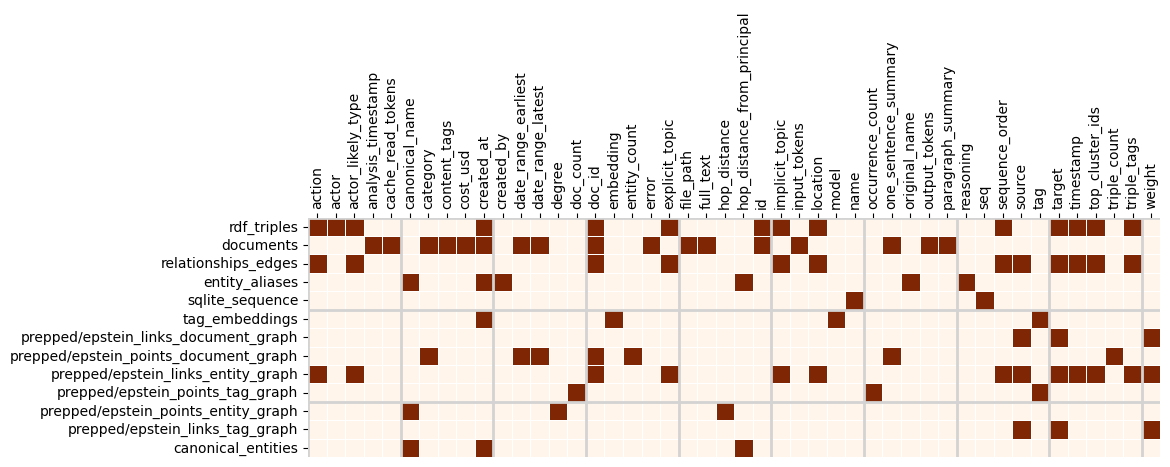

In [8]:
def view_tables_and_their_columns(columns_info: dict) -> dict[str, list[str]]:
    """
    make and view a heatmap of a table of tables_and_their_columns where rows are 
    the keys and columns columns are the union of the strings in their lists
    and value of cells are 1 if the column is present in the table, else 0
    """
    import pandas as pd
    from oplot.matrix import heatmap_sns  # pip install oplot

    all_columns = set()
    for cols in columns_info.values():
        all_columns.update(cols)    
    all_columns = sorted(all_columns)
    heatmap_data = pd.DataFrame(0, index=columns_info.keys(), columns=all_columns)
    for table, cols in columns_info.items():
        for col in cols:
            heatmap_data.at[table, col] = 1

    return heatmap_sns(heatmap_data)

view_tables_and_their_columns(columns_info)

### Have a look at some tables

In [9]:
print(f"{tables['documents'].shape}")
print(tables['documents'].iloc[0].to_string())

(25232, 17)
id                                                                      1
doc_id                                             HOUSE_OVERSIGHT_010477
file_path                       data/001_split/HOUSE_OVERSIGHT_010477.txt
one_sentence_summary    A heavily illustrated book excerpt and photo c...
paragraph_summary       This document is an excerpt from a book about ...
date_range_earliest                                                  1969
date_range_latest                                                 2016-01
category                                                     book_excerpt
content_tags            ["biographical_documentation","photography_and...
analysis_timestamp                               2025-11-14T06:38:19.665Z
input_tokens                                                          3.0
output_tokens                                                      2988.0
cache_read_tokens                                                 18280.0
cost_usd                  

In [10]:
print(tables['documents'].iloc[0].one_sentence_summary)

print(tables['documents'].iloc[0].paragraph_summary)
len(tables['documents'].iloc[0].full_text)

A heavily illustrated book excerpt and photo collection from a biography of Jeffrey Epstein, documenting his properties, associates, legal proceedings, and lifestyle from the 1960s through 2016.
This document is an excerpt from a book about Jeffrey Epstein's life and criminal history, titled 'The Powerful Billionaire, the Ex Scandal That Undid Him, and All the Justice That Money Can Buy: The Shocking True Story of Jeffrey Epstein.' The document contains photographs and captions spanning from Epstein's 1969 high school yearbook through 2016, documenting his properties (Palm Beach, Manhattan townhouse, Little Saint James island in the U.S. Virgin Islands), his associates and social connections (Leslie Wexner, Ghislaine Maxwell, Donald Trump, Prince Andrew, Stephen Hawking, and others), his legal troubles and conviction, his jail sentence at Palm Beach County Stockade, and his Gulfstream aircraft. The document tracks key events including his 2005 criminal investigation beginning, his 2008

9376

In [11]:
print(f"{tables['relationships_edges'].shape}")
tables['relationships_edges'].iloc[0]

(107030, 12)


source                                                 Jeffrey Epstein
target                                  Lafayette High School yearbook
action                                                 photographed in
timestamp                                                          NaN
location                                                           NaN
doc_id                                          HOUSE_OVERSIGHT_010477
sequence_order                                                       0
actor_likely_type                                                  NaN
triple_tags          ["biographical_photo","high_school","identity_...
explicit_topic                              biographical documentation
implicit_topic                                   early life background
top_cluster_ids                                             [16,26,27]
Name: 0, dtype: object

In [12]:
print(f"{tables['tag_embeddings'].shape}")
tables['tag_embeddings'].iloc[0]

(29689, 4)


tag                                         email_communication
embedding     [0.02476835877039858,-0.009844271982040728,-0....
model                        Qwen3-Embedding-0.6B-ONNX-fp16-32d
created_at                                  2025-11-16 07:37:48
Name: 0, dtype: str

In [ ]:
print(f"tags are unique: {tables['tag_embeddings'].tag.nunique() == len(tables['tag_embeddings'])}")


tags are unique: True


# Prepare data for Cosmograph

## prepare_entity_graph_data

In [16]:
from imbed_data_prep.epstein_files import prepare_entity_graph_data

# First call computes and caches to tables; subsequent calls load from cache
cosmo_data = prepare_entity_graph_data(data_dir=data_rootdir, tables=tables)
points_eg = cosmo_data['points']
links_eg = cosmo_data['links']

print(f"Points: {points_eg.shape}, Links: {links_eg.shape}")
points_eg.head(10)

Points: (55880, 3), Links: (65467, 13)


,canonical_name,degree,hop_distance
0,Jeffrey Epstein,6494,0.0
1,unknown person A,4144,NaN
2,Donald Trump,1728,1.0
3,Alan M. Dershowitz,898,1.0
4,Edward Snowden,763,2.0
5,Ehud Barak,743,1.0
6,unknown person B,508,NaN
7,Steve Bannon,428,1.0
8,Barack Obama,402,1.0
9,Bank of America Merrill Lynch,378,2.0


In [17]:
print(f"{points_eg.shape}")
points_eg.iloc[2]

(55880, 3)


canonical_name    Donald Trump
degree                    1728
hop_distance               1.0
Name: 2, dtype: object

In [18]:
print(f"{links_eg.shape}")
links_eg.iloc[0]

(65467, 13)


source                                                 Jeffrey Epstein
target                                  Lafayette High School yearbook
weight                                                               1
action                                                 photographed in
timestamp                                                          NaN
location                                                           NaN
doc_id                                          HOUSE_OVERSIGHT_010477
sequence_order                                                       0
actor_likely_type                                                  NaN
triple_tags          ["biographical_photo","high_school","identity_...
explicit_topic                              biographical documentation
implicit_topic                                   early life background
top_cluster_ids                                             [16,26,27]
Name: 0, dtype: object

In [19]:
from cosmograph import cosmo 

cosmo(
    points=points_eg,
    links=links_eg,

    point_id_by="canonical_name",
    point_color_by="hop_distance",
    point_color_strategy="interpolate",
    point_size_by="degree",
    point_size_scale=0.8,
    point_label_by="canonical_name",

    link_source_by="source",
    link_target_by="target",
    link_color_by="action",
    link_arrows=True,
    link_width_by="weight",

    show_dynamic_labels=True,
)

Cosmograph(background_color=None, components_display_state_mode=None, focused_point_ring_color=None, hovered_p…

## prepare_document_graph_data

Documents as nodes, linked by shared entities, tags, or topics.

In [20]:
from imbed_data_prep.epstein_files import prepare_document_graph_data

# First call computes and caches to tables; subsequent calls load from cache
cosmo_data_doc = prepare_document_graph_data(
    data_dir=data_rootdir, tables=tables, link_by='shared_entities', min_shared=3
)
points_dg = cosmo_data_doc['points']
links_dg = cosmo_data_doc['links']

print(f"Points: {points_dg.shape}, Links: {links_dg.shape}")
points_dg.head(10)

Reading parquet files from /Users/thorwhalen/Dropbox/_odata/app_data/imbed/saves/epstein_files
Resolving entity aliases...
Building document links by 'shared_entities'...
Computing document pairs...
  223662 document pairs with >= 3 shared shared_entities
Building document points...
  18126 document nodes
Done.
Points: (18126, 7), Links: (223662, 3)


,doc_id,entity_count,triple_count,one_sentence_summary,category,date_range_earliest,date_range_latest
0,TEXT-001-HOUSE_OVERSIGHT_027594,103,112,An extended SMS/iChat conversation between Jef...,mixed_document,2019-03-09T16:16:31,2019-03-31T13:09:51
1,HOUSE_OVERSIGHT_017088_part7,115,107,A book excerpt discussing Alan Dershowitz's ca...,book_excerpt,1969-07,2011-04
2,HOUSE_OVERSIGHT_027594,86,107,An SMS/iChat message exchange between Jeffrey ...,mixed_document,2019-03-09,2019-03-31
3,HOUSE_OVERSIGHT_027460,2,103,An iMessage chat conversation between Jeffrey ...,mixed_document,2018-11-11,2018-11-28
4,HOUSE_OVERSIGHT_022445,86,85,A compilation of feedback and comments from ac...,mixed_document,2018-11,2018-11
5,HOUSE_OVERSIGHT_017088_part4,96,79,A legal autobiography and memoir by Alan Dersh...,book_excerpt,1969,2011
6,HOUSE_OVERSIGHT_025452,63,75,An iMessage conversation between Jeffrey Epste...,mixed_document,2019-05-09T17:55:44,2019-05-20T19:32:56
7,HOUSE_OVERSIGHT_020447_part1,88,70,A 2018 Hoover Institution research report anal...,report,1949-12-01,2018-10-24
8,HOUSE_OVERSIGHT_027165,7,69,An iMessage conversation between Jeffrey Epste...,mixed_document,2017-02-19,2017-02-24
9,HOUSE_OVERSIGHT_025707,2,67,An iMessage conversation between Jeffrey Epste...,transcript,2018-08-17T08:53:05,2018-08-23T15:07:01


In [21]:
print(f"{points_dg.shape}")
points_dg.iloc[0]

(18126, 7)


doc_id                                    TEXT-001-HOUSE_OVERSIGHT_027594
entity_count                                                          103
triple_count                                                          112
one_sentence_summary    An extended SMS/iChat conversation between Jef...
category                                                   mixed_document
date_range_earliest                                   2019-03-09T16:16:31
date_range_latest                                     2019-03-31T13:09:51
Name: 0, dtype: object

In [22]:
print(f"{links_dg.shape}")
links_dg.iloc[0]

(223662, 3)


source    HOUSE_OVERSIGHT_010477
target    HOUSE_OVERSIGHT_010487
weight                         4
Name: 0, dtype: object

In [ ]:
from cosmograph import cosmo 

cosmo(
    points=points_dg,
    links=links_dg,

    point_id_by="doc_id",
    point_color_by="category",
    # point_color_strategy="palette",
    point_size_by="triple_count",
    point_size_scale=0.8,
    point_label_by="one_sentence_summary",

    link_source_by="source",
    link_target_by="target",
    link_width_by="weight",

    show_dynamic_labels=True,
)

Cosmograph(background_color=None, components_display_state_mode=None, focused_point_ring_color=None, hovered_p…

## prepare_tag_graph_data

Tags as nodes, linked by co-occurrence or embedding similarity.

In [24]:
from imbed_data_prep.epstein_files import prepare_tag_graph_data

# First call computes and caches to tables; subsequent calls load from cache
cosmo_data_tag = prepare_tag_graph_data(
    data_dir=data_rootdir, tables=tables, link_by='co_occurrence', min_co_occurrence=5
)
points_tg = cosmo_data_tag['points']
links_tg = cosmo_data_tag['links']

print(f"Points: {points_tg.shape}, Links: {links_tg.shape}")
points_tg.head(10)

Reading parquet files from /Users/thorwhalen/Dropbox/_odata/app_data/imbed/saves/epstein_files
Parsing tags from triples...
  73111 unique tags found
Computing tag co-occurrences...
  2768 tag pairs with >= 5 co-occurrences
Building tag points...
  73111 tag nodes
Done.
Points: (73111, 3), Links: (2768, 3)


,tag,occurrence_count,doc_count
0,email_communication,6139,2012
1,personal_correspondence,2048,1190
2,political_commentary,1394,1079
3,legal_representation,1002,628
4,networking,930,576
5,legal_strategy,809,669
6,travel_planning,745,566
7,witness_testimony,717,471
8,reputation_management,665,523
9,media_coverage,604,477


In [40]:
print(f"{points_tg.shape}")
points_tg.iloc[0]

(73111, 3)


tag                 email_communication
occurrence_count                   6139
doc_count                          2012
Name: 0, dtype: object

In [41]:
print(f"{links_tg.shape}")
links_tg.iloc[0]

(2768, 3)


source    property_ownership
target           real_estate
weight                    21
Name: 0, dtype: object

In [25]:
from cosmograph import cosmo 

cosmo(
    points=points_tg,
    links=links_tg,

    point_id_by="tag",
    point_color_by="doc_count",
    point_color_strategy="interpolate",
    point_size_by="occurrence_count",
    point_size_scale=0.8,
    point_label_by="tag",

    link_source_by="source",
    link_target_by="target",
    link_width_by="weight",

    show_dynamic_labels=True,
)

Cosmograph(background_color=None, components_display_state_mode=None, focused_point_ring_color=None, hovered_p…

# Planarize tag embeddings

In [26]:
tag_embeddings = tables['tag_embeddings']

# check that all tag embeddings are from the same model
assert len(tag_embeddings.model.value_counts()) == 1, (
    "Expected all tag embeddings to be from the same model, but found multiple models in the 'model' column of the 'tag_embeddings' table."
)

print(f"{tag_embeddings.shape}")
tag_embeddings.iloc[0]

(29689, 4)


tag                                         email_communication
embedding     [0.02476835877039858,-0.009844271982040728,-0....
model                        Qwen3-Embedding-0.6B-ONNX-fp16-32d
created_at                                  2025-11-16 07:37:48
Name: 0, dtype: str

In [27]:
# noticed that the embeddings are stored as strings, so we need to convert them back to lists of floats
if isinstance(tag_embeddings.embedding.iloc[0], str):
    # convert all the string representations of the vectors back to a list of floats
    import ast

    tag_embeddings['embedding'] = tag_embeddings['embedding'].apply(ast.literal_eval)

    assert isinstance(tag_embeddings.embedding.iloc[0], list), (
        "Expected the 'embedding' column to contain lists of floats after conversion, but found a different type."
    )

assert tag_embeddings.tag.nunique() == len(tag_embeddings), (
    "Expected all tags to be unique in the 'tag_embeddings' table, but found duplicates in the 'tag' column."
)

In [ ]:
from functools import partial
from imbed import planar_embeddings

umap_xy = planar_embeddings.umap(tag_embeddings.set_index('tag').embedding, egress=partial(planar_embeddings.cast_to_df, x_col='umap_x', y_col='umap_y'))
umap_xy.index.name = 'tag'
print(f"{umap_xy.shape}")
umap_xy.iloc[0]

(29689, 2)


umap_x    3.708341
umap_y   -1.111008
Name: email_communication, dtype: float32

In [34]:
tables['prepped/umap_xy'] = umap_xy

In [35]:
tables['prepped/umap_xy']

,umap_x,umap_y
tag,,
email_communication,3.708341,-1.111008
personal_correspondence,3.538218,-0.798783
legal_representation,2.006694,1.619817
political_commentary,-0.108037,4.093203
instant_messaging,3.923044,-1.150523
...,...,...
aircraft_market,8.656129,1.258312
business_networks,5.214253,2.192550
domestic_policy_defense,-0.089097,2.141617


In [37]:
documents = tables['documents']
documents.content_tags.iloc[0]

'["biographical_documentation","photography_and_captions","property_documentation","criminal_proceedings","legal_conviction","jail_sentence","high_society_connections","financial_wealth","sex_offender_registry","celebrity_associations","political_figures","travel_and_aircraft","charitable_foundations","social_events"]'

# Scrap

## Get some stats about all the tables

In [ ]:
import lkj
from pprint import pformat

# Even more informative version that shows statistics
def comprehensive_handle_special_types(obj):
    """Most informative while still being manageable"""
    
    # Check if it's a pandas DataFrame
    if hasattr(obj, 'columns') and hasattr(obj, 'index') and hasattr(obj, 'shape'):
        try:
            rows, cols = obj.shape
            col_names = list(obj.columns)
            if cols <= 6:
                col_display = col_names
            else:
                col_display = col_names[:4] + ['...'] + col_names[-1:]
            return f"<DataFrame({rows}x{cols}): {col_display}>"
        except:
            return f"<DataFrame>"
    
    # Check if it's a pandas Series
    elif hasattr(obj, 'head') and hasattr(obj, 'dtype') and hasattr(obj, 'index'):
        try:
            length = len(obj)
            dtype = str(obj.dtype)
            
            # For small series, show more
            if length <= 6:
                values = obj.tolist()
                return f"<Series[{dtype}]({length}): {values}>"
            
            # Check if it looks like value_counts results (has count/frequency pattern)
            if hasattr(obj, 'index') and len(obj) > 10:
                head_items = obj.head(2)
                tail_items = obj.tail(1)
                index_sample = head_items.index.tolist()
                values_sample = head_items.tolist()
                
                if dtype in ['int64', 'int32'] and all(isinstance(v, (int, float)) for v in values_sample):
                    # Looks like value counts
                    total = obj.sum() if hasattr(obj, 'sum') else 'unknown'
                    return f"<ValueCounts[{length} categories, total={total}]: top={list(zip(index_sample, values_sample))}>"
                else:
                    return f"<Series[{dtype}]({length}): idx={index_sample}, vals={values_sample}...>"
            
            # Regular series handling
            head_vals = obj.head(3).tolist()
            
            if dtype == 'object':
                try:
                    unique_count = obj.nunique()
                    return f"<Series[{dtype}]({length}, {unique_count} unique): {head_vals}...>"
                except:
                    return f"<Series[{dtype}]({length}): {head_vals}...>"
            
            return f"<Series[{dtype}]({length}): {head_vals}...>"
        except Exception as e:
            return f"<Series[error: {str(e)[:50]}]>"
    
    # Check if it's a numpy array 
    elif hasattr(obj, 'shape') and hasattr(obj, 'dtype'):
        try:
            shape = obj.shape
            dtype = str(obj.dtype)
            size = obj.size
            
            if size <= 8:
                return f"<Array[{dtype}]{shape}: {obj.tolist()}>"
            else:
                flat = obj.flatten()
                sample = flat[:4].tolist()
                return f"<Array[{dtype}]{shape}({size}): {sample}...>"
        except:
            return f"<Array>"
    
    return obj



# Test comprehensive version
print("Testing comprehensive handle_special_types...")
result = lkj.truncate_dict_values(
    dict(all_info), 
    d_ingress=comprehensive_handle_special_types,
    max_list_size=5,
    max_string_size=150
)

string = pformat(result)
print(string)

Testing comprehensive handle_special_types...
{'canonical_entities': ((26690, 3),
                        ['canonical_name',
                         'hop_distance_from_principal',
                         'created_at'],
                        '<Series[object](3): [\'"I\\\'m like a Heidi '
                        'Fleiss"\', np.int64(2), \'2025-11-18 15:17:38\']>',
                        "<DataFrame(3x3): ['canonical_name', "
                        "'hop_distance_from_principal', 'created_at']>",
                        "<DataFrame(8x1): ['hop_distance_from_principal']>"),
 'documents': ((25232, 17),
               ['id',
                'doc_id',
                'file_path',
                'one_sentence_summary',
                'paragraph_summary'],
               "<Series[object](17): idx=['id', 'doc_id'], vals=[np.int64(1), "
               "'HOUSE_OVERSIGHT_010477']...>",
               "<DataFrame(3x17): ['id', 'doc_id', 'file_path', "
               "'one_sentence_summary', 